In [3]:
# ===========================================================
# STEP 1: Install Libraries & Import Required Modules
# ===========================================================
# Purpose:
# 1. Install required libraries
# 2. Import modules for image processing, visualization,
#    deep learning, evaluation, and augmentation
# 3. Prepare environment for BUSBRA dataset validation
# ===========================================================

# -----------------------------------------------------------
# Install Required Libraries
# -----------------------------------------------------------
!pip install -q albumentations
!pip install -q pydot
!pip install -q keras-tuner

# -----------------------------------------------------------
# Import Standard Python Libraries
# -----------------------------------------------------------
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Import TensorFlow and Keras Modules
# -----------------------------------------------------------
import tensorflow as tf

from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import (
    to_categorical,
    plot_model
)

from tensorflow.keras import metrics

# -----------------------------------------------------------
# Import Scikit-learn Modules
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -----------------------------------------------------------
# Import Albumentations for Image Augmentation
# -----------------------------------------------------------
import albumentations as A

# -----------------------------------------------------------
# Set Random Seed for Reproducibility
# -----------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------------------
# Verify TensorFlow and GPU Availability
# -----------------------------------------------------------
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available and activated")
    print("GPU Device:", gpus)
else:
    print("GPU not available, running on CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.4 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
GPU is available and activated
GPU Device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ===========================================================
# STEP 2: Mount Google Drive & Count BUSBRA Images/Masks
# ===========================================================
# Purpose:
# 1. Mount Google Drive
# 2. Access BUSBRA dataset
# 3. Count total images and masks
# 4. Verify dataset integrity
# ===========================================================

# -----------------------------------------------------------
# Mount Google Drive
# -----------------------------------------------------------
from google.colab import drive
import os

drive.mount('/content/drive')

# -----------------------------------------------------------
# Define BUSBRA Dataset Paths
# -----------------------------------------------------------
dataset_path = '/content/drive/MyDrive/Colab Notebooks/BUSBRA'

images_path = os.path.join(dataset_path, 'Images')
masks_path  = os.path.join(dataset_path, 'Masks')

# -----------------------------------------------------------
# Accepted Image Extensions
# -----------------------------------------------------------
image_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

# -----------------------------------------------------------
# Count Images
# -----------------------------------------------------------
image_files = sorted([
    f for f in os.listdir(images_path)
    if f.lower().endswith(image_ext)
])

# -----------------------------------------------------------
# Count Masks
# -----------------------------------------------------------
mask_files = sorted([
    f for f in os.listdir(masks_path)
    if f.lower().endswith(image_ext)
])

# -----------------------------------------------------------
# Print Dataset Statistics
# -----------------------------------------------------------
print("======================================")
print("BUSBRA Dataset Statistics")
print("======================================")

print(f"Total Images : {len(image_files)}")
print(f"Total Masks  : {len(mask_files)}")

# -----------------------------------------------------------
# Verify Matching Counts
# -----------------------------------------------------------
if len(image_files) == len(mask_files):
    print("\nDataset integrity check PASSED")
    print("Images and masks are properly matched")
else:
    print("\nDataset integrity check FAILED")
    print("Mismatch between image and mask counts")

print("======================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BUSBRA Dataset Statistics
Total Images : 1875
Total Masks  : 1875

Dataset integrity check PASSED
Images and masks are properly matched


In [5]:
# ===========================================================
# STEP 3: Inspect BUSBRA Dataset Files
# ===========================================================
# Purpose:
# 1. Inspect Images and Masks folders
# 2. Count image and mask files
# 3. Check whether filenames are matched
# 4. Display sample filenames for verification
# ===========================================================

import os

# -----------------------------------------------------------
# Define accepted image extensions
# -----------------------------------------------------------
image_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

# -----------------------------------------------------------
# Read image and mask filenames
# -----------------------------------------------------------
image_files = sorted([
    f for f in os.listdir(images_path)
    if f.lower().endswith(image_ext)
])

mask_files = sorted([
    f for f in os.listdir(masks_path)
    if f.lower().endswith(image_ext)
])

# -----------------------------------------------------------
# Display basic counts
# -----------------------------------------------------------
print("======================================")
print("BUSBRA Dataset Inspection")
print("======================================")
print(f"Number of Images: {len(image_files)}")
print(f"Number of Masks : {len(mask_files)}")
print("======================================")

# -----------------------------------------------------------
# Show sample files
# -----------------------------------------------------------
print("\nSample Image Files:")
for f in image_files[:5]:
    print(" ", f)

print("\nSample Mask Files:")
for f in mask_files[:5]:
    print(" ", f)

# -----------------------------------------------------------
# Check image-mask count consistency
# -----------------------------------------------------------
if len(image_files) == len(mask_files):
    print("\nImage-mask count check PASSED")
else:
    print("\nImage-mask count check FAILED")
    print("The number of images and masks is not equal.")

BUSBRA Dataset Inspection
Number of Images: 1875
Number of Masks : 1875

Sample Image Files:
  bus_0001-l.png
  bus_0001-r.png
  bus_0002-l.png
  bus_0002-r.png
  bus_0003-l.png

Sample Mask Files:
  mask_0001-l.png
  mask_0001-r.png
  mask_0002-l.png
  mask_0002-r.png
  mask_0003-l.png

Image-mask count check PASSED


In [6]:
# ===========================================================
# Check BUSBRA Image and Mask Filename Patterns
# ===========================================================

print("Sample image files:")
for f in image_files[:20]:
    print(f)

print("\nSample mask files:")
for f in mask_files[:20]:
    print(f)

Sample image files:
bus_0001-l.png
bus_0001-r.png
bus_0002-l.png
bus_0002-r.png
bus_0003-l.png
bus_0003-r.png
bus_0004-l.png
bus_0004-r.png
bus_0005-l.png
bus_0005-r.png
bus_0006-s.png
bus_0007-l.png
bus_0007-r.png
bus_0008-l.png
bus_0008-r.png
bus_0009-l.png
bus_0009-r.png
bus_0010-l.png
bus_0010-r.png
bus_0011-l.png

Sample mask files:
mask_0001-l.png
mask_0001-r.png
mask_0002-l.png
mask_0002-r.png
mask_0003-l.png
mask_0003-r.png
mask_0004-l.png
mask_0004-r.png
mask_0005-l.png
mask_0005-r.png
mask_0006-s.png
mask_0007-l.png
mask_0007-r.png
mask_0008-l.png
mask_0008-r.png
mask_0009-l.png
mask_0009-r.png
mask_0010-l.png
mask_0010-r.png
mask_0011-l.png


Total images: 1875
Matched image-mask pairs: 1875


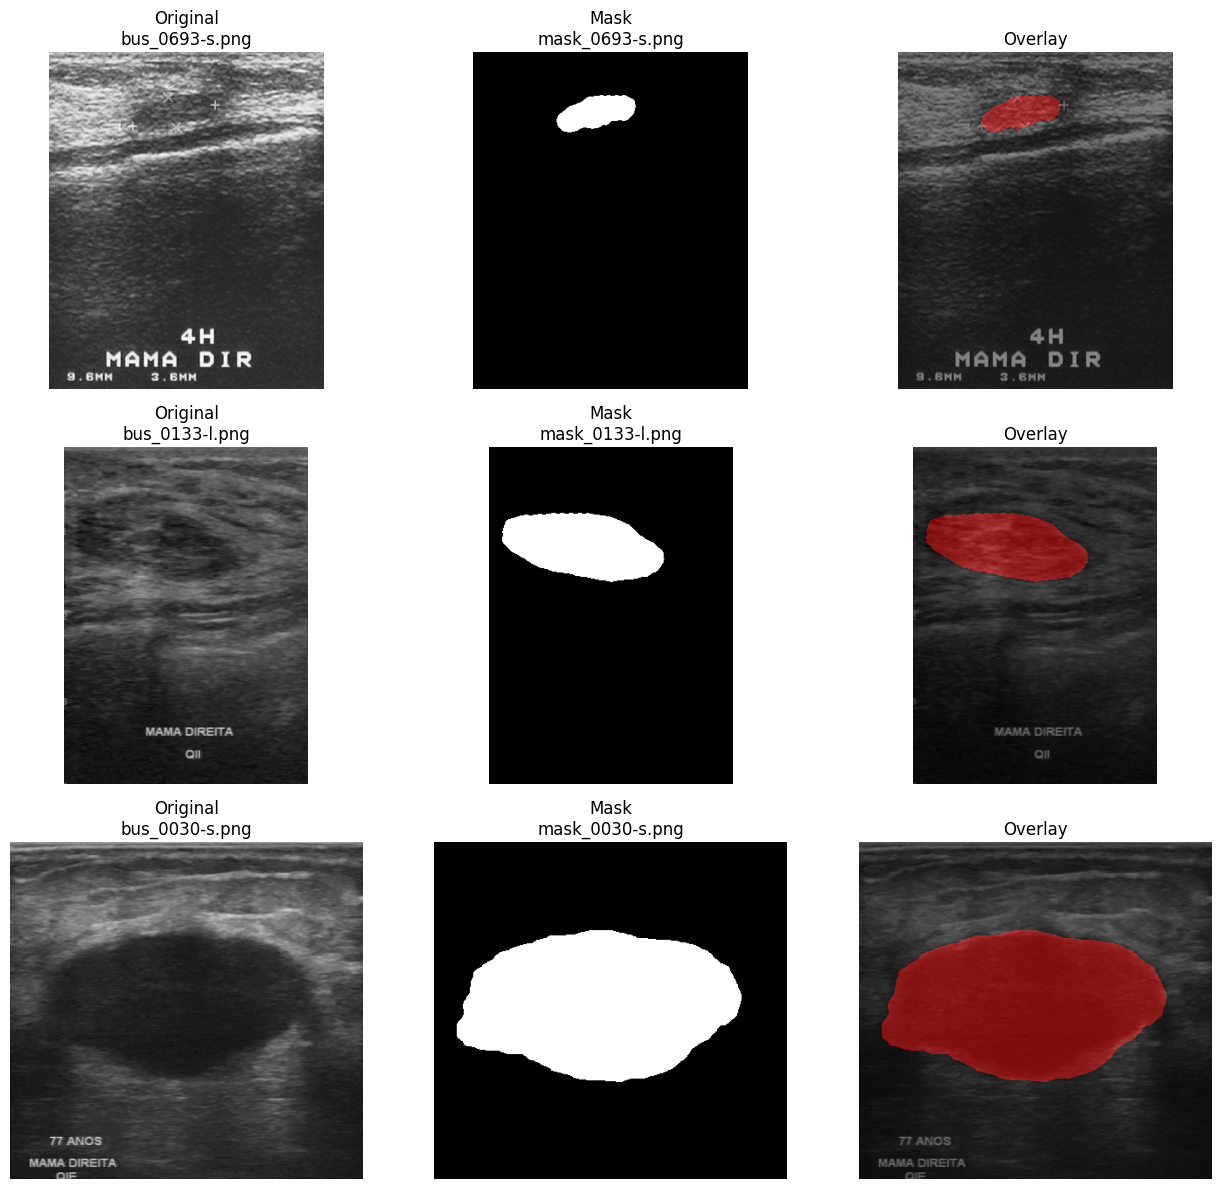

In [7]:
# ===========================================================
# STEP 4: Visualize BUSBRA Sample Images, Masks, and Overlays
# ===========================================================

import random
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import os

def find_matching_mask(img_file, masks_path):
    """
    BUSBRA matching rule:
    bus_0001-l.png -> mask_0001-l.png
    bus_0001-r.png -> mask_0001-r.png
    bus_0006-s.png -> mask_0006-s.png
    """
    mask_file = img_file.replace("bus_", "mask_", 1)
    mask_path = os.path.join(masks_path, mask_file)

    if os.path.exists(mask_path):
        return mask_file, mask_path
    else:
        return None, None


def visualize_busbra_samples(images_path, masks_path, num_samples=5, alpha=0.45):

    image_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

    image_files = sorted([
        f for f in os.listdir(images_path)
        if f.lower().endswith(image_ext)
    ])

    valid_pairs = []

    for img_file in image_files:
        mask_file, mask_path = find_matching_mask(img_file, masks_path)

        if mask_path is not None:
            valid_pairs.append((img_file, mask_file))

    print("Total images:", len(image_files))
    print("Matched image-mask pairs:", len(valid_pairs))

    if len(valid_pairs) == 0:
        raise ValueError("No matched image-mask pairs found.")

    num_samples = min(num_samples, len(valid_pairs))
    selected_pairs = random.sample(valid_pairs, num_samples)

    fig, axes = plt.subplots(
        nrows=num_samples,
        ncols=3,
        figsize=(13, 4 * num_samples)
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (img_file, mask_file) in enumerate(selected_pairs):

        img_path = os.path.join(images_path, img_file)
        mask_path = os.path.join(masks_path, mask_file)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        if image.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(
                mask,
                (image.shape[1], image.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        mask_binary = (mask > 0).astype(np.uint8) * 255

        mask_colored = np.zeros_like(image)
        mask_colored[:, :, 0] = mask_binary

        overlay = cv2.addWeighted(image, 1 - alpha, mask_colored, alpha, 0)

        axes[row_idx, 0].imshow(image)
        axes[row_idx, 0].set_title(f"Original\n{img_file}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(mask_binary, cmap="gray")
        axes[row_idx, 1].set_title(f"Mask\n{mask_file}")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title("Overlay")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_busbra_samples(
    images_path=images_path,
    masks_path=masks_path,
    num_samples=3,
    alpha=0.45
)

Enter BUSBRA image filename, e.g., bus_0001-l.png: bus_0001-l.png


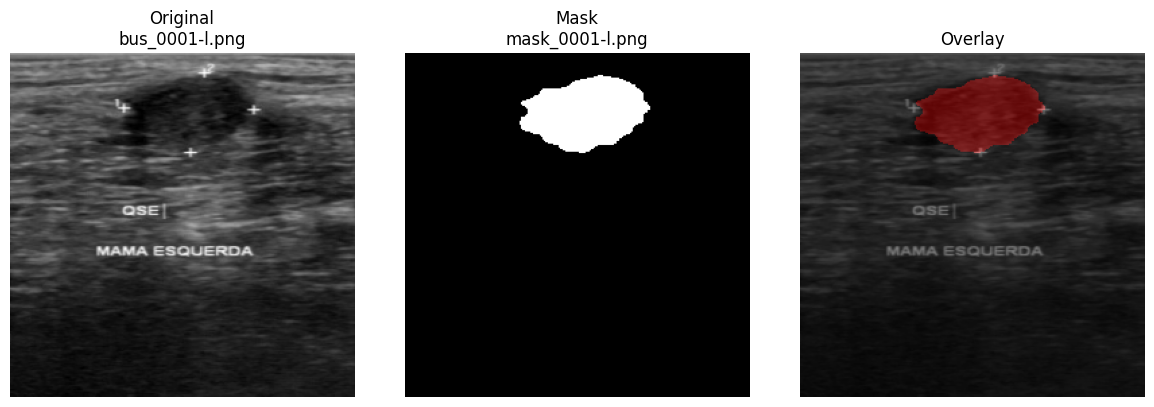

In [8]:

# ===========================================================
# STEP 5: Load Specific BUSBRA Image and Display Mask + Overlay
# ===========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Enter BUSBRA image filename
# Example: bus_0001-l.png, bus_0001-r.png, bus_0006-s.png
# -----------------------------------------------------------
user_input = input("Enter BUSBRA image filename, e.g., bus_0001-l.png: ").strip()

image_path = os.path.join(images_path, user_input)

mask_filename = user_input.replace("bus_", "mask_", 1)
mask_path = os.path.join(masks_path, mask_filename)

# -----------------------------------------------------------
# Validate paths
# -----------------------------------------------------------
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

if not os.path.exists(mask_path):
    raise FileNotFoundError(f"Mask not found: {mask_path}")

# -----------------------------------------------------------
# Load image and mask
# -----------------------------------------------------------
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError(f"Could not read image: {image_path}")

if mask is None:
    raise ValueError(f"Could not read mask: {mask_path}")

# -----------------------------------------------------------
# Resize image and mask
# -----------------------------------------------------------
image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

# Convert mask to binary
mask_binary = (mask > 0).astype(np.uint8) * 255

# -----------------------------------------------------------
# Create overlay
# -----------------------------------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

mask_colored = np.zeros_like(image_rgb)
mask_colored[:, :, 0] = mask_binary

overlay = cv2.addWeighted(image_rgb, 0.65, mask_colored, 0.35, 0)

# -----------------------------------------------------------
# Display results
# -----------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title(f"Original\n{user_input}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_binary, cmap="gray")
plt.title(f"Mask\n{mask_filename}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# ===========================================================
# STEP 6: Load Full BUSBRA Dataset into Arrays with Cache
# ===========================================================

import os
import cv2
import numpy as np

# -----------------------------------------------------------
# Cache file path
# -----------------------------------------------------------
cache_path = os.path.join(dataset_path, "busbra_256_cached_dataset.npz")

def load_busbra_dataset_with_cache(images_path, masks_path, img_size=(256, 256), cache_path=None):
    """
    Load BUSBRA images and masks.
    If cached file exists, load X, Y, image_names directly.
    Otherwise, process images/masks and save cache.
    """

    # -------------------------------------------------------
    # Load saved cache if available
    # -------------------------------------------------------
    if cache_path is not None and os.path.exists(cache_path):
        print("Cached dataset found. Loading saved arrays...")
        data = np.load(cache_path, allow_pickle=True)

        X = data["X"]
        Y = data["Y"]
        image_names = data["image_names"]

        print("======================================")
        print("BUSBRA Dataset Loaded from Cache")
        print("======================================")
        print("Loaded image-mask pairs :", X.shape[0])
        print("Image shape             :", X.shape[1:])
        print("Mask shape              :", Y.shape[1:])
        print("Unique mask values      :", np.unique(Y))
        print("Cache file              :", cache_path)
        print("======================================")

        return X, Y, image_names

    # -------------------------------------------------------
    # Otherwise process dataset from Images and Masks folders
    # -------------------------------------------------------
    print("No cached dataset found. Processing BUSBRA images and masks...")

    image_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

    image_files = sorted([
        f for f in os.listdir(images_path)
        if f.lower().endswith(image_ext)
    ])

    images = []
    masks = []
    image_names = []
    missing_masks = []

    for idx, img_file in enumerate(image_files, start=1):

        if idx % 100 == 0:
            print(f"Processed {idx}/{len(image_files)} files...")

        mask_file = img_file.replace("bus_", "mask_", 1)

        img_path = os.path.join(images_path, img_file)
        mask_path = os.path.join(masks_path, mask_file)

        if not os.path.exists(mask_path):
            missing_masks.append(img_file)
            continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Could not read image: {img_file}")
            continue

        img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print(f"Could not read mask: {mask_file}")
            continue

        mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)

        images.append(img)
        masks.append(mask)
        image_names.append(img_file)

    X = np.array(images, dtype=np.float32)
    Y = np.array(masks, dtype=np.uint8)

    X = np.expand_dims(X, axis=-1)
    Y = np.expand_dims(Y, axis=-1)
    image_names = np.array(image_names)

    # -------------------------------------------------------
    # Save cache for future use
    # -------------------------------------------------------
    if cache_path is not None:
        np.savez_compressed(
            cache_path,
            X=X,
            Y=Y,
            image_names=image_names
        )
        print("\nCached dataset saved successfully.")

    print("======================================")
    print("BUSBRA Dataset Loaded")
    print("======================================")
    print("Total image files found :", len(image_files))
    print("Loaded image-mask pairs :", X.shape[0])
    print("Missing masks           :", len(missing_masks))
    print("Image shape             :", X.shape[1:])
    print("Mask shape              :", Y.shape[1:])
    print("Unique mask values      :", np.unique(Y))
    print("Cache file              :", cache_path)
    print("======================================")

    return X, Y, image_names


# -----------------------------------------------------------
# Load BUSBRA Dataset
# -----------------------------------------------------------
X, Y, image_names = load_busbra_dataset_with_cache(
    images_path=images_path,
    masks_path=masks_path,
    img_size=(256, 256),
    cache_path=cache_path
)

Cached dataset found. Loading saved arrays...
BUSBRA Dataset Loaded from Cache
Loaded image-mask pairs : 1875
Image shape             : (256, 256, 1)
Mask shape              : (256, 256, 1)
Unique mask values      : [0 1]
Cache file              : /content/drive/MyDrive/Colab Notebooks/BUSBRA/busbra_256_cached_dataset.npz


In [10]:
# ===========================================================
# STEP 7: Train/Validation/Test Split with Data Augmentation
# ===========================================================
# Purpose:
# 1. Split BUSBRA dataset into train, validation, and test sets
# 2. Use binary segmentation classes: background and lesion
# 3. Apply on-the-fly augmentation for training images/masks
# 4. One-hot encode masks for U-Net training
# ===========================================================

import numpy as np
from sklearn.model_selection import train_test_split
import albumentations as A
from tensorflow.keras.utils import to_categorical

# -----------------------------------------------------------
# Define binary segmentation classes
# -----------------------------------------------------------
class_names = ['background', 'lesion']
num_classes = len(class_names)

# -----------------------------------------------------------
# First split: Train+Validation and Test
# 80% train+val, 20% test
# -----------------------------------------------------------
X_train_val, X_test, Y_train_val, Y_test, names_train_val, names_test = train_test_split(
    X,
    Y,
    image_names,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# -----------------------------------------------------------
# Second split: Train and Validation
# 90% train, 10% validation from train_val
# Final ratio: 72% train, 8% validation, 20% test
# -----------------------------------------------------------
X_train, X_val, Y_train, Y_val, names_train, names_val = train_test_split(
    X_train_val,
    Y_train_val,
    names_train_val,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

# -----------------------------------------------------------
# Define data augmentation for training set
# -----------------------------------------------------------
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        border_mode=0,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.4)
])

# -----------------------------------------------------------
# Function to apply augmentation to one batch
# -----------------------------------------------------------
def augment_batch(X_batch, Y_batch):
    X_aug = []
    Y_aug = []

    for img, mask in zip(X_batch, Y_batch):

        img_2d = img.squeeze()
        mask_2d = mask.squeeze()

        augmented = train_transform(
            image=img_2d,
            mask=mask_2d
        )

        img_aug = augmented['image'][..., np.newaxis].astype(np.float32)
        mask_aug = augmented['mask'][..., np.newaxis].astype(np.uint8)

        # Keep mask binary after augmentation
        mask_aug = (mask_aug > 0).astype(np.uint8)

        X_aug.append(img_aug)
        Y_aug.append(mask_aug)

    return np.array(X_aug, dtype=np.float32), np.array(Y_aug, dtype=np.uint8)

# -----------------------------------------------------------
# One-hot encode masks
# -----------------------------------------------------------
def one_hot_encode_masks(masks, num_classes):
    masks = masks.squeeze(-1).astype(np.int32)
    return to_categorical(masks, num_classes=num_classes).astype(np.float32)

Y_train_onehot = one_hot_encode_masks(Y_train, num_classes)
Y_val_onehot   = one_hot_encode_masks(Y_val, num_classes)
Y_test_onehot  = one_hot_encode_masks(Y_test, num_classes)

# -----------------------------------------------------------
# Verify shapes
# -----------------------------------------------------------
print("======================================")
print("BUSBRA Train/Validation/Test Split")
print("======================================")
print("X_train shape       :", X_train.shape)
print("Y_train shape       :", Y_train.shape)
print("Y_train_onehot shape:", Y_train_onehot.shape)

print("\nX_val shape         :", X_val.shape)
print("Y_val shape         :", Y_val.shape)
print("Y_val_onehot shape  :", Y_val_onehot.shape)

print("\nX_test shape        :", X_test.shape)
print("Y_test shape        :", Y_test.shape)
print("Y_test_onehot shape :", Y_test_onehot.shape)

# -----------------------------------------------------------
# Pixel distribution in training set
# -----------------------------------------------------------
pixel_classes_train = np.argmax(Y_train_onehot, axis=-1).flatten()
unique, counts = np.unique(pixel_classes_train, return_counts=True)

pixel_distribution = {
    class_names[int(k)]: int(v)
    for k, v in zip(unique, counts)
}

print("\nPixel distribution in training set:")
print(pixel_distribution)

print("======================================")
print("Ready for Step 8: Build U-Net Model")
print("======================================")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


BUSBRA Train/Validation/Test Split
X_train shape       : (1350, 256, 256, 1)
Y_train shape       : (1350, 256, 256, 1)
Y_train_onehot shape: (1350, 256, 256, 2)

X_val shape         : (150, 256, 256, 1)
Y_val shape         : (150, 256, 256, 1)
Y_val_onehot shape  : (150, 256, 256, 2)

X_test shape        : (375, 256, 256, 1)
Y_test shape        : (375, 256, 256, 1)
Y_test_onehot shape : (375, 256, 256, 2)

Pixel distribution in training set:
{'background': 80927937, 'lesion': 7545663}
Ready for Step 8: Build U-Net Model


In [11]:
# ===========================================================
# STEP 8: Build U-Net Model for Hyperparameter Search
# ===========================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, Input
from keras_tuner import HyperModel

# -----------------------------------------------------------
# Dice Loss for Binary/Two-Class Segmentation
# -----------------------------------------------------------
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true[..., 1], [-1])
    y_pred_f = tf.reshape(y_pred[..., 1], [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

    return 1 - dice


def combined_ce_dice_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return ce + dl


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true[..., 1], [-1])
    y_pred_f = tf.reshape(y_pred[..., 1], [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

    return dice

# -----------------------------------------------------------
# Convolutional Block
# -----------------------------------------------------------
def convBlock(inputs, filters, kernel_size=(3, 3), l2_reg=1e-4):

    x = layers.Conv2D(
        filters,
        kernel_size,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2_reg)
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(
        filters,
        kernel_size,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(
        filters,
        kernel_size,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

# -----------------------------------------------------------
# U-Net HyperModel
# -----------------------------------------------------------
class UNetHyperModel(HyperModel):

    def __init__(self, input_shape=(256, 256, 1), num_classes=2):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):

        inputs = Input(self.input_shape)

        filters = hp.Choice('filters', [16, 32, 64])
        dropoutRate = hp.Float('dropoutRate', 0.1, 0.4, step=0.1)
        l2_reg = hp.Float('l2_reg', 1e-5, 1e-3, sampling='log')

        # Encoder
        conv1 = convBlock(inputs, filters, l2_reg=l2_reg)
        pool1 = layers.MaxPooling2D((2, 2))(conv1)
        pool1 = layers.Dropout(dropoutRate)(pool1)

        conv2 = convBlock(pool1, filters * 2, l2_reg=l2_reg)
        pool2 = layers.MaxPooling2D((2, 2))(conv2)
        pool2 = layers.Dropout(dropoutRate)(pool2)

        conv3 = convBlock(pool2, filters * 4, l2_reg=l2_reg)
        pool3 = layers.MaxPooling2D((2, 2))(conv3)
        pool3 = layers.Dropout(dropoutRate)(pool3)

        conv4 = convBlock(pool3, filters * 8, l2_reg=l2_reg)
        pool4 = layers.MaxPooling2D((2, 2))(conv4)
        pool4 = layers.Dropout(dropoutRate)(pool4)

        # Bottleneck
        conv5 = convBlock(pool4, filters * 16, l2_reg=l2_reg)

        # Decoder
        up6 = layers.Conv2DTranspose(filters * 8, (3, 3), strides=(2, 2), padding='same')(conv5)
        up6 = layers.concatenate([up6, conv4])
        up6 = layers.Dropout(dropoutRate)(up6)
        conv6 = convBlock(up6, filters * 8, l2_reg=l2_reg)

        up7 = layers.Conv2DTranspose(filters * 4, (3, 3), strides=(2, 2), padding='same')(conv6)
        up7 = layers.concatenate([up7, conv3])
        up7 = layers.Dropout(dropoutRate)(up7)
        conv7 = convBlock(up7, filters * 4, l2_reg=l2_reg)

        up8 = layers.Conv2DTranspose(filters * 2, (3, 3), strides=(2, 2), padding='same')(conv7)
        up8 = layers.concatenate([up8, conv2])
        up8 = layers.Dropout(dropoutRate)(up8)
        conv8 = convBlock(up8, filters * 2, l2_reg=l2_reg)

        up9 = layers.Conv2DTranspose(filters, (3, 3), strides=(2, 2), padding='same')(conv8)
        up9 = layers.concatenate([up9, conv1])
        up9 = layers.Dropout(dropoutRate)(up9)
        conv9 = convBlock(up9, filters, l2_reg=l2_reg)

        outputs = layers.Conv2D(self.num_classes, (1, 1), activation='softmax')(conv9)

        learning_rate = hp.Float('learning_rate', 1e-5, 5e-4, sampling='log')

        model = Model(inputs, outputs)

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss=combined_ce_dice_loss,
            metrics=[
                'accuracy',
                dice_coefficient,
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')
            ]
        )

        return model

# -----------------------------------------------------------
# Initialize HyperModel
# -----------------------------------------------------------
hypermodel = UNetHyperModel(
    input_shape=(256, 256, 1),
    num_classes=2
)

print("Step 8 completed: BUSBRA U-Net HyperModel is ready.")

Step 8 completed: BUSBRA U-Net HyperModel is ready.


In [12]:
# ===========================================================
# STEP 9: Hyperparameter Search with Keras Tuner for BUSBRA
# ===========================================================

from keras_tuner import RandomSearch
import keras_tuner
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
import json
import os

# -----------------------------------------------------------
# Save paths
# -----------------------------------------------------------
tuner_dir = os.path.join(dataset_path, "unet_tuner")
project_name = "BUSBRA_binary_segmentation"

model_save_path = os.path.join(dataset_path, "best_busbra_unet_model.keras")
hyperparam_path = os.path.join(dataset_path, "best_busbra_unet_hyperparameters.json")

# -----------------------------------------------------------
# Early stopping
# -----------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# -----------------------------------------------------------
# If saved model already exists, load it
# -----------------------------------------------------------
if os.path.exists(model_save_path) and os.path.exists(hyperparam_path):

    print("Saved BUSBRA model found. Loading model and hyperparameters...")

    best_model = load_model(
        model_save_path,
        custom_objects={
            "combined_ce_dice_loss": combined_ce_dice_loss,
            "dice_loss": dice_loss,
            "dice_coefficient": dice_coefficient
        },
        compile=True
    )

    with open(hyperparam_path, "r") as f:
        best_hyperparameters = json.load(f)

    print("Best model loaded successfully.")
    print("\nBest Hyperparameters:")
    print(best_hyperparameters)

# -----------------------------------------------------------
# Otherwise run hyperparameter search
# -----------------------------------------------------------
else:

    print("No saved BUSBRA model found. Starting hyperparameter search...")

    unet_hypermodel = UNetHyperModel(
        input_shape=(256, 256, 1),
        num_classes=2
    )

    tuner = RandomSearch(
        hypermodel=unet_hypermodel,
        objective=keras_tuner.Objective("val_dice_coefficient", direction="max"),
        max_trials=10,
        executions_per_trial=1,
        directory=tuner_dir,
        project_name=project_name,
        overwrite=False
    )

    tuner.search(
        X_train,
        Y_train_onehot,
        validation_data=(X_val, Y_val_onehot),
        epochs=50,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    best_model = tuner.get_best_models(num_models=1)[0]
    best_hparams_obj = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hyperparameters = best_hparams_obj.values

    best_model.save(model_save_path)

    with open(hyperparam_path, "w") as f:
        json.dump(best_hyperparameters, f, indent=4)

    print("\nBest BUSBRA U-Net model saved at:")
    print(model_save_path)

    print("\nBest BUSBRA hyperparameters saved at:")
    print(hyperparam_path)

    print("\n=== Best Hyperparameters ===")
    print(f"Filters           : {best_hparams_obj.get('filters')}")
    print(f"Dropout Rate      : {best_hparams_obj.get('dropoutRate')}")
    print(f"L2 Regularization : {best_hparams_obj.get('l2_reg')}")
    print(f"Learning Rate     : {best_hparams_obj.get('learning_rate')}")

Saved BUSBRA model found. Loading model and hyperparameters...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 238 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best model loaded successfully.

Best Hyperparameters:
{'filters': 32, 'dropoutRate': 0.1, 'l2_reg': 0.0003072821882297506, 'learning_rate': 0.00017170890789985807}


In [13]:
# ===========================================================
# Load Saved BUSBRA Best Model and Hyperparameters
# ===========================================================

from tensorflow.keras.models import load_model
import json
import os

# -----------------------------------------------------------
# Define save paths
# -----------------------------------------------------------
model_save_path = os.path.join(
    dataset_path,
    "best_busbra_unet_model.keras"
)

hyperparam_path = os.path.join(
    dataset_path,
    "best_busbra_unet_hyperparameters.json"
)

# -----------------------------------------------------------
# Load saved BUSBRA model
# -----------------------------------------------------------
best_model = load_model(
    model_save_path,
    custom_objects={
        "combined_ce_dice_loss": combined_ce_dice_loss,
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    },
    compile=True
)

print("Best BUSBRA U-Net model loaded successfully.")

# -----------------------------------------------------------
# Load hyperparameters
# -----------------------------------------------------------
with open(hyperparam_path, "r") as f:
    best_hyperparameters = json.load(f)

print("\nLoaded Hyperparameters:")
print(best_hyperparameters)

Best BUSBRA U-Net model loaded successfully.

Loaded Hyperparameters:
{'filters': 32, 'dropoutRate': 0.1, 'l2_reg': 0.0003072821882297506, 'learning_rate': 0.00017170890789985807}


In [14]:
# ===========================================================
# Load Saved BUSBRA U-Net Model and Hyperparameters
# ===========================================================

from tensorflow.keras.models import load_model
import json
import os

# -----------------------------------------------------------
# Define saved paths
# -----------------------------------------------------------
model_save_path = os.path.join(
    dataset_path,
    "best_busbra_unet_model.keras"
)

hyperparam_path = os.path.join(
    dataset_path,
    "best_busbra_unet_hyperparameters.json"
)

# -----------------------------------------------------------
# Load saved model
# -----------------------------------------------------------
best_model = load_model(
    model_save_path,
    custom_objects={
        "combined_ce_dice_loss": combined_ce_dice_loss,
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    },
    compile=True
)

print("Best BUSBRA U-Net model loaded successfully.")

# -----------------------------------------------------------
# Load hyperparameters
# -----------------------------------------------------------
with open(hyperparam_path, 'r') as f:
    best_hyperparameters = json.load(f)

print("\nLoaded Hyperparameters:")
print(best_hyperparameters)


Best BUSBRA U-Net model loaded successfully.

Loaded Hyperparameters:
{'filters': 32, 'dropoutRate': 0.1, 'l2_reg': 0.0003072821882297506, 'learning_rate': 0.00017170890789985807}


In [15]:
# ===========================================================
# STEP 10: Load Saved BUSBRA U-Net Model and Fine-Tune
# ===========================================================

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

import json
import os

# -----------------------------------------------------------
# Define paths
# -----------------------------------------------------------
model_save_path = os.path.join(
    dataset_path,
    "best_busbra_unet_model.keras"
)

finetuned_model_path = os.path.join(
    dataset_path,
    "best_busbra_unet_finetuned.keras"
)

auc_save_path = os.path.join(
    dataset_path,
    "busbra_overall_auc.json"
)

# -----------------------------------------------------------
# Load base U-Net model
# -----------------------------------------------------------
U_net_model = load_model(
    model_save_path,
    custom_objects={
        "combined_ce_dice_loss": combined_ce_dice_loss,
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    },
    compile=True
)

print("Best BUSBRA U-Net model loaded successfully.")

# -----------------------------------------------------------
# If fine-tuned model already exists, load it directly
# -----------------------------------------------------------
if os.path.exists(finetuned_model_path):

    print("Fine-tuned BUSBRA model already exists.")
    print("Loading saved fine-tuned model...")

    U_net_model = load_model(
        finetuned_model_path,
        custom_objects={
            "combined_ce_dice_loss": combined_ce_dice_loss,
            "dice_loss": dice_loss,
            "dice_coefficient": dice_coefficient
        },
        compile=True
    )

    print("Fine-tuned model loaded successfully.")

else:

    print("No fine-tuned model found.")
    print("Starting BUSBRA fine-tuning...")

    # -------------------------------------------------------
    # Define callbacks
    # -------------------------------------------------------
    checkpoint = ModelCheckpoint(
        finetuned_model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    # -------------------------------------------------------
    # Fine-tune model
    # -------------------------------------------------------
    history = U_net_model.fit(
        X_train,
        Y_train_onehot,
        validation_data=(X_val, Y_val_onehot),
        epochs=50,
        batch_size=8,
        callbacks=[checkpoint, early_stopping, reduce_lr],
        verbose=1
    )

    # -------------------------------------------------------
    # Save AUC history
    # -------------------------------------------------------
    overall_auc_train = history.history['auc']
    overall_auc_val = history.history['val_auc']

    with open(auc_save_path, 'w') as f:
        json.dump({
            'train_auc': overall_auc_train,
            'val_auc': overall_auc_val
        }, f, indent=4)

    print(f"\nOverall AUC history saved at:")
    print(auc_save_path)

    # -------------------------------------------------------
    # Print summary
    # -------------------------------------------------------
    print("\nTraining history keys:")
    print(history.history.keys())

    print("\nFirst 5 epochs Training AUC:")
    print(overall_auc_train[:5])

    print("\nFirst 5 epochs Validation AUC:")
    print(overall_auc_val[:5])

print("\nStep 10 completed successfully.")

Best BUSBRA U-Net model loaded successfully.
Fine-tuned BUSBRA model already exists.
Loading saved fine-tuned model...
Fine-tuned model loaded successfully.

Step 10 completed successfully.


In [16]:
# ===========================================================
# STEP 12: Evaluate BUSBRA U-Net Model
# ===========================================================

def print_metrics(dataset_name, metrics_values, model):

    metric_dict = dict(zip(model.metrics_names, metrics_values))

    print(f"\n=== {dataset_name} Metrics ===")

    for key, value in metric_dict.items():
        print(f"{key}: {value:.4f}")

# -----------------------------------------------------------
# Evaluate Training Set
# -----------------------------------------------------------
train_metrics = U_net_model.evaluate(
    X_train,
    Y_train_onehot,
    verbose=1,
    return_dict=True
)

print("\n=== BUSBRA Training Set Metrics ===")
for key, value in train_metrics.items():
    print(f"{key}: {value:.4f}")

# -----------------------------------------------------------
# Evaluate Validation Set
# -----------------------------------------------------------
val_metrics = U_net_model.evaluate(
    X_val,
    Y_val_onehot,
    verbose=1,
    return_dict=True
)

print("\n=== BUSBRA Validation Set Metrics ===")
for key, value in val_metrics.items():
    print(f"{key}: {value:.4f}")

# -----------------------------------------------------------
# Evaluate Test Set
# -----------------------------------------------------------
test_metrics = U_net_model.evaluate(
    X_test,
    Y_test_onehot,
    verbose=1,
    return_dict=True
)

print("\n=== BUSBRA Test Set Metrics ===")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 47s 517ms/step - accuracy: 0.9936 - auc: 0.9994 - dice_coefficient: 0.9579 - loss: 0.1784 - precision: 0.9936 - recall: 0.9936

=== BUSBRA Training Set Metrics ===
accuracy: 0.9936
auc: 0.9994
dice_coefficient: 0.9579
loss: 0.1784
precision: 0.9936
recall: 0.9936
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.9777 - auc: 0.9879 - dice_coefficient: 0.8687 - loss: 0.3806 - precision: 0.9777 - recall: 0.9777

=== BUSBRA Validation Set Metrics ===
accuracy: 0.9777
auc: 0.9879
dice_coefficient: 0.8687
loss: 0.3806
precision: 0.9777
recall: 0.9777
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9791 - auc: 0.9899 - dice_coefficient: 0.8781 - loss: 0.3528 - precision: 0.9791 - recall: 0.9791

=== BUSBRA Test Set Metrics ===
accuracy: 0.9791
auc: 0.9899
dice_coefficient: 0.8781
loss: 0.3528
precision: 0.9791
recall: 0.9791


In [17]:
# ===========================================================
# STEP 13: Compute Per-Class Metrics
# ===========================================================
# Purpose:
# 1. Compute pixel-wise metrics per class: precision, recall, F1-score
# 2. Compute confusion matrix per class
# 3. Compute ROC-AUC per class (one-vs-rest)
# ===========================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def compute_per_class_metrics(model, X, Y_onehot, class_names):
    """
    Compute per-class metrics for multi-class segmentation.

    Args:
        model: Trained U-Net model
        X: Input images (num_samples, H, W, 1)
        Y_onehot: Ground truth masks (num_samples, H, W, num_classes)
        class_names: List of class names
    """
    # Predict probabilities
    Y_pred_prob = model.predict(X, batch_size=8)

    # Convert to class indices
    Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()
    Y_true = np.argmax(Y_onehot, axis=-1).flatten()

    # -----------------------------
    # Classification report and confusion matrix
    print("\n=== Classification Report ===")
    print(classification_report(Y_true, Y_pred, target_names=class_names, zero_division=0))

    print("\n=== Confusion Matrix ===")
    cm = confusion_matrix(Y_true, Y_pred, labels=list(range(len(class_names))))
    print(cm)

    # -----------------------------
    # ROC-AUC per class (one-vs-rest)
    print("\n=== ROC-AUC per class ===")
    for i, cls in enumerate(class_names):
        y_true_binary = (Y_true == i).astype(int)
        y_pred_prob_cls = Y_pred_prob[..., i].flatten()
        try:
            auc = roc_auc_score(y_true_binary, y_pred_prob_cls)
            print(f"{cls}: {auc:.4f}")
        except ValueError:
            print(f"{cls}: Not enough samples to compute AUC")


In [18]:
# ===========================================================
# STEP 13: Compute Pixel-Level Per-Class Metrics for BUSBRA
# ===========================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def compute_busbra_per_class_metrics(model, X, Y_onehot, class_names, batch_size=8):
    """
    Computes pixel-wise metrics for BUSBRA binary segmentation.

    Classes:
        0 = background
        1 = lesion
    """

    # -------------------------------------------------------
    # Predict probabilities
    # -------------------------------------------------------
    Y_pred_prob = model.predict(
        X,
        batch_size=batch_size,
        verbose=1
    )

    # -------------------------------------------------------
    # Convert probabilities to class labels
    # -------------------------------------------------------
    Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()
    Y_true = np.argmax(Y_onehot, axis=-1).flatten()

    # -------------------------------------------------------
    # Classification report
    # -------------------------------------------------------
    print("\n=== BUSBRA Pixel-Level Classification Report ===")
    print(
        classification_report(
            Y_true,
            Y_pred,
            target_names=class_names,
            zero_division=0,
            digits=4
        )
    )

    # -------------------------------------------------------
    # Confusion matrix
    # -------------------------------------------------------
    print("\n=== BUSBRA Pixel-Level Confusion Matrix ===")
    cm = confusion_matrix(
        Y_true,
        Y_pred,
        labels=list(range(len(class_names)))
    )
    print(cm)

    print("\nConfusion Matrix Meaning:")
    print("Rows    = True classes")
    print("Columns = Predicted classes")
    print("Class 0 = background")
    print("Class 1 = lesion")

    # -------------------------------------------------------
    # ROC-AUC per class
    # -------------------------------------------------------
    print("\n=== BUSBRA ROC-AUC per Class ===")

    for i, cls in enumerate(class_names):
        y_true_binary = (Y_true == i).astype(int)
        y_pred_prob_cls = Y_pred_prob[..., i].flatten()

        try:
            auc = roc_auc_score(y_true_binary, y_pred_prob_cls)
            print(f"{cls}: {auc:.4f}")
        except ValueError:
            print(f"{cls}: Not enough samples to compute AUC")

    # -------------------------------------------------------
    # Binary lesion AUC
    # -------------------------------------------------------
    print("\n=== BUSBRA Lesion-Specific AUC ===")
    lesion_true = (Y_true == 1).astype(int)
    lesion_prob = Y_pred_prob[..., 1].flatten()

    lesion_auc = roc_auc_score(lesion_true, lesion_prob)
    print(f"Lesion AUC: {lesion_auc:.4f}")

    return cm


# -----------------------------------------------------------
# Run Step 13 on Test Set
# -----------------------------------------------------------
class_names = ["background", "lesion"]

cm_test = compute_busbra_per_class_metrics(
    model=U_net_model,
    X=X_test,
    Y_onehot=Y_test_onehot,
    class_names=class_names,
    batch_size=8
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 374ms/step

=== BUSBRA Pixel-Level Classification Report ===
              precision    recall  f1-score   support

  background     0.9861    0.9910    0.9886  22369459
      lesion     0.9040    0.8585    0.8807   2206541

    accuracy                         0.9791  24576000
   macro avg     0.9450    0.9248    0.9346  24576000
weighted avg     0.9787    0.9791    0.9789  24576000


=== BUSBRA Pixel-Level Confusion Matrix ===
[[22168196   201263]
 [  312147  1894394]]

Confusion Matrix Meaning:
Rows    = True classes
Columns = Predicted classes
Class 0 = background
Class 1 = lesion

=== BUSBRA ROC-AUC per Class ===
background: 0.9834
lesion: 0.9834

=== BUSBRA Lesion-Specific AUC ===
Lesion AUC: 0.9834


47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step


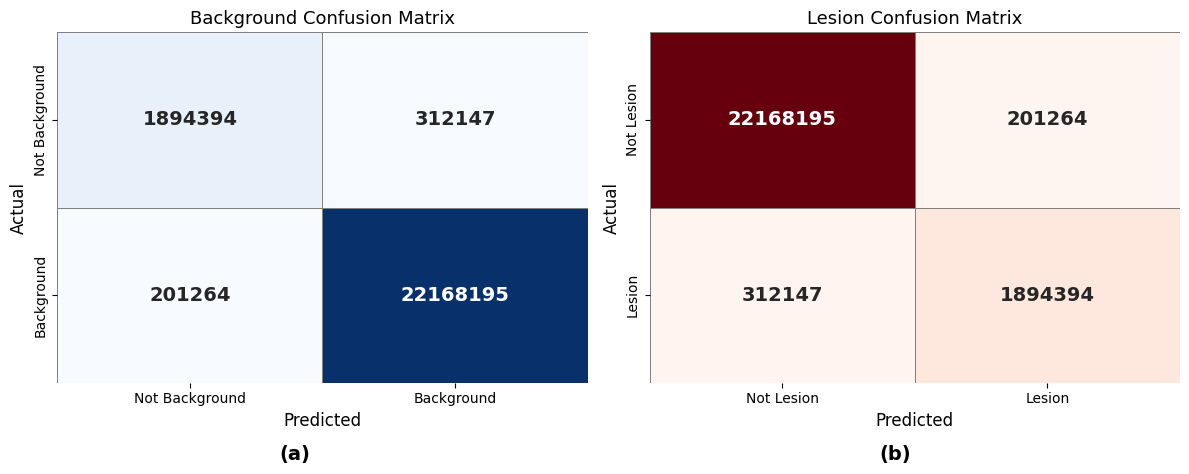

In [19]:
# ===========================================================
# STEP 14a: BUSBRA Confusion Matrix per Class (Side by Side)
# ===========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# -----------------------------------------------------------
# Predict test masks
# -----------------------------------------------------------
Y_true = np.argmax(Y_test_onehot, axis=-1).flatten()

Y_pred_prob = U_net_model.predict(
    X_test,
    batch_size=8,
    verbose=1
)

Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()

# -----------------------------------------------------------
# BUSBRA classes
# -----------------------------------------------------------
class_names = ['Background', 'Lesion']
subplot_labels = ['(a)', '(b)']
colors = ['Blues', 'Reds']

# -----------------------------------------------------------
# Create subplots
# -----------------------------------------------------------
fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(12, 5)
)

# -----------------------------------------------------------
# Generate one-vs-rest confusion matrix for each class
# -----------------------------------------------------------
for i, cls in enumerate(class_names):

    y_true_bin = (Y_true == i).astype(int)
    y_pred_bin = (Y_pred == i).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=colors[i],
        xticklabels=[f'Not {cls}', cls],
        yticklabels=[f'Not {cls}', cls],
        cbar=False,
        linewidths=0.5,
        linecolor='gray',
        annot_kws={"size": 14, "weight": "bold"},
        ax=axes[i]
    )

    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)
    axes[i].set_title(f'{cls} Confusion Matrix', fontsize=13)

# -----------------------------------------------------------
# Add subplot labels
# -----------------------------------------------------------
for i, label in enumerate(subplot_labels):
    x_pos = (i + 0.5) / len(class_names)
    fig.text(
        x_pos,
        0.02,
        label,
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step


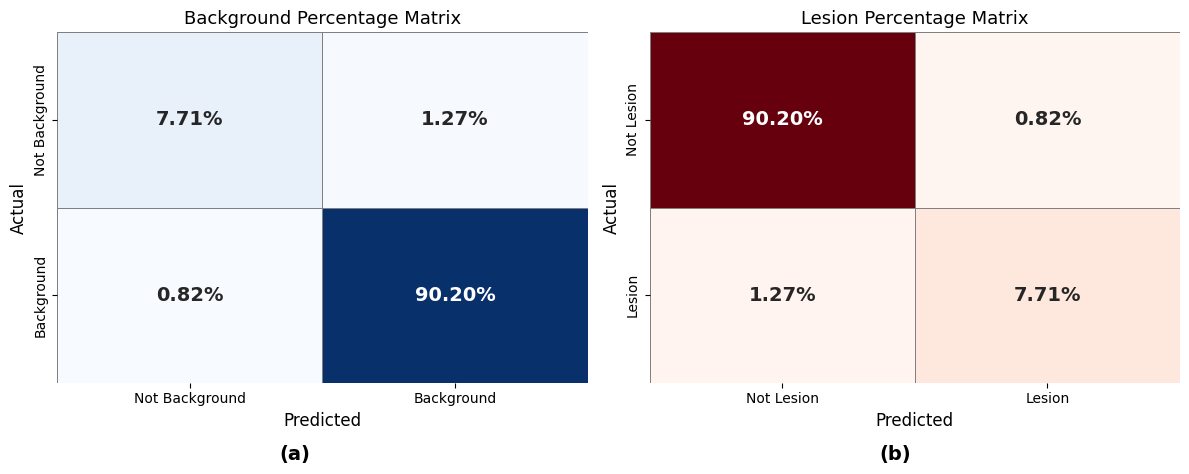

In [20]:
# ===========================================================
# STEP 14b: BUSBRA Confusion Matrix Percentages per Class
# ===========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# -----------------------------------------------------------
# Flatten predictions for test set
# -----------------------------------------------------------
Y_true = np.argmax(Y_test_onehot, axis=-1).flatten()

Y_pred_prob = U_net_model.predict(
    X_test,
    batch_size=8,
    verbose=1
)

Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()

# -----------------------------------------------------------
# BUSBRA classes
# -----------------------------------------------------------
class_names = ['Background', 'Lesion']
subplot_labels = ['(a)', '(b)']
colors = ['Blues', 'Reds']

# -----------------------------------------------------------
# Create figure
# -----------------------------------------------------------
fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(12, 5)
)

# -----------------------------------------------------------
# Plot one-vs-rest percentage confusion matrix per class
# -----------------------------------------------------------
for i, cls in enumerate(class_names):

    y_true_bin = (Y_true == i).astype(int)
    y_pred_bin = (Y_pred == i).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    cm_percent = cm.astype('float') / cm.sum() * 100
    cm_percent_str = np.array([
        ["{0:.2f}%".format(val) for val in row]
        for row in cm_percent
    ])

    sns.heatmap(
        cm_percent,
        annot=cm_percent_str,
        fmt='',
        cmap=colors[i],
        xticklabels=[f'Not {cls}', cls],
        yticklabels=[f'Not {cls}', cls],
        cbar=False,
        linewidths=0.5,
        linecolor='gray',
        annot_kws={"size": 14, "weight": "bold"},
        ax=axes[i]
    )

    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)
    axes[i].set_title(f'{cls} Percentage Matrix', fontsize=13)

# -----------------------------------------------------------
# Add subplot labels
# -----------------------------------------------------------
for i, label in enumerate(subplot_labels):
    x_pos = (i + 0.5) / len(class_names)
    fig.text(
        x_pos,
        0.02,
        label,
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step


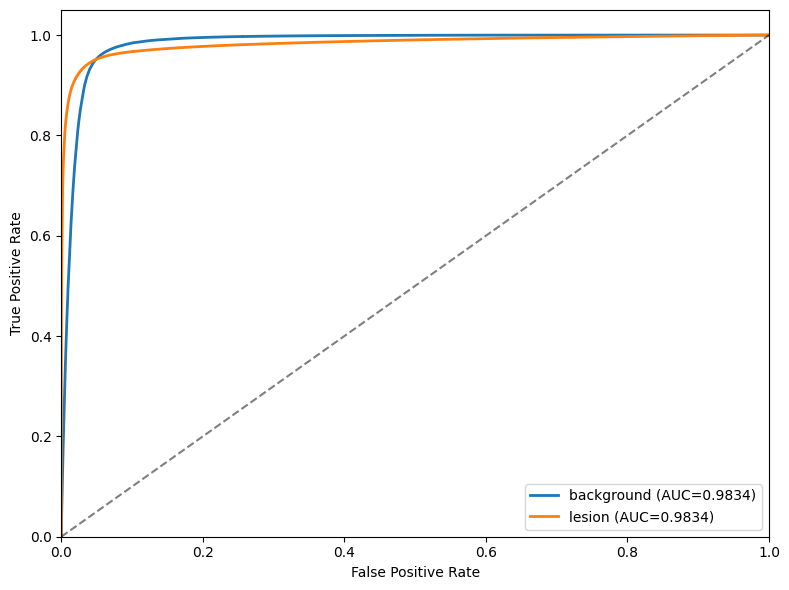

In [21]:
# ===========================================================
# STEP 14k: BUSBRA Per-Class ROC-AUC Curves
# ===========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# -----------------------------------------------------------
# Flatten true labels
# -----------------------------------------------------------
Y_true_flat = np.argmax(Y_test_onehot, axis=-1).flatten()

# -----------------------------------------------------------
# Predict probabilities
# -----------------------------------------------------------
Y_pred_prob = U_net_model.predict(
    X_test,
    batch_size=8,
    verbose=1
)

# -----------------------------------------------------------
# BUSBRA class names
# -----------------------------------------------------------
class_names = ['background', 'lesion']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

# -----------------------------------------------------------
# Compute ROC-AUC per class
# -----------------------------------------------------------
for i, cls in enumerate(class_names):

    y_true_bin = (Y_true_flat == i).astype(int)
    y_pred_prob_cls = Y_pred_prob[..., i].flatten()

    try:
        fpr, tpr, _ = roc_curve(y_true_bin, y_pred_prob_cls)
        roc_auc = auc(fpr, tpr)

    except ValueError:
        fpr, tpr, roc_auc = None, None, np.nan
        print(f"Cannot compute ROC for class '{cls}'")

    fpr_dict[cls] = fpr
    tpr_dict[cls] = tpr
    auc_dict[cls] = roc_auc

# -----------------------------------------------------------
# Plot ROC curves
# -----------------------------------------------------------
plt.figure(figsize=(8, 6))

for cls in class_names:
    if fpr_dict[cls] is not None:
        plt.plot(
            fpr_dict[cls],
            tpr_dict[cls],
            linewidth=2,
            label=f'{cls} (AUC={auc_dict[cls]:.4f})'
        )

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.5,
    label='_nolegend_'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [22]:
from google.colab import drive
drive.mount('/content/drive')

# -----------------------------------------------------------
# Save the trained BUSBRA U-Net model to Google Drive
# -----------------------------------------------------------
model_save_path = '/content/drive/MyDrive/Colab Notebooks/best_trained_unet_model_BUSBRA.keras'

U_net_model.save(model_save_path)

print(f"✅ BUSBRA trained model saved permanently at:")
print(model_save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ BUSBRA trained model saved permanently at:
/content/drive/MyDrive/Colab Notebooks/best_trained_unet_model_BUSBRA.keras


In [23]:
# ===========================================================
# STEP: Load Saved BUSBRA U-Net Model
# ===========================================================

from tensorflow.keras.models import load_model

# -----------------------------------------------------------
# Path to the saved BUSBRA model
# -----------------------------------------------------------
model_load_path = '/content/drive/MyDrive/Colab Notebooks/best_trained_unet_model_BUSBRA.keras'

# -----------------------------------------------------------
# Load trained BUSBRA U-Net model
# -----------------------------------------------------------
U_net_model = load_model(
    model_load_path,
    custom_objects={
        "combined_ce_dice_loss": combined_ce_dice_loss,
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    },
    compile=True
)

print("✅ Trained BUSBRA U-Net model loaded successfully!")

# -----------------------------------------------------------
# Display model summary
# -----------------------------------------------------------
U_net_model.summary()

✅ Trained BUSBRA U-Net model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_4[0][0]  

 Total params: 37,707,656 (143.84 MB)

 Trainable params: 12,566,274 (47.94 MB)

 Non-trainable params: 8,832 (34.50 KB)

 Optimizer params: 25,132,550 (95.87 MB)

In [24]:
# ===========================================================
# STEP 15: Generate Predicted Masks with Trained BUSBRA U-Net
# ===========================================================

import numpy as np

# -----------------------------------------------------------
# Predict segmentation probabilities
# -----------------------------------------------------------
Y_train_pred = U_net_model.predict(
    X_train,
    batch_size=8,
    verbose=1
)

Y_val_pred = U_net_model.predict(
    X_val,
    batch_size=8,
    verbose=1
)

Y_test_pred = U_net_model.predict(
    X_test,
    batch_size=8,
    verbose=1
)

# -----------------------------------------------------------
# Convert probabilities to predicted class labels
# Class 0 = background
# Class 1 = lesion
# -----------------------------------------------------------
Y_train_pred_class = np.argmax(Y_train_pred, axis=-1)

Y_val_pred_class = np.argmax(Y_val_pred, axis=-1)

Y_test_pred_class = np.argmax(Y_test_pred, axis=-1)

# -----------------------------------------------------------
# Quick sanity checks
# -----------------------------------------------------------
print("======================================")
print("BUSBRA Predicted Mask Shapes")
print("======================================")

print("Train predictions shape      :", Y_train_pred_class.shape)
print("Validation predictions shape :", Y_val_pred_class.shape)
print("Test predictions shape       :", Y_test_pred_class.shape)

print("\nUnique predicted classes in test set:")
print(np.unique(Y_test_pred_class))

print("======================================")

169/169 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step
BUSBRA Predicted Mask Shapes
Train predictions shape      : (1350, 256, 256)
Validation predictions shape : (150, 256, 256)
Test predictions shape       : (375, 256, 256)

Unique predicted classes in test set:
[0 1]


In [25]:
# ===========================================================
# STEP 16: Extract Morphology Features from BUSBRA U-Net Masks
# ===========================================================

import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

def extract_morphology_features(images, masks):
    """
    Extract morphology features from predicted BUSBRA masks.

    images: grayscale images, shape = (N, H, W, 1)
    masks : predicted masks, shape = (N, H, W), where:
            0 = background
            1 = lesion
    """

    feature_list = []

    for i in range(len(images)):

        mask = masks[i]

        lesion_mask = (mask == 1).astype(np.uint8)

        if np.sum(lesion_mask) == 0:
            feature_list.append({
                "area": 0,
                "perimeter": 0,
                "circularity": 0,
                "solidity": 0,
                "centroid_x": np.nan,
                "centroid_y": np.nan
            })
            continue

        labeled_mask = label(lesion_mask)
        props = regionprops(labeled_mask)

        largest_region = max(props, key=lambda x: x.area)

        area = largest_region.area
        perimeter = largest_region.perimeter
        circularity = 4 * np.pi * area / (perimeter ** 2 + 1e-6)
        solidity = largest_region.solidity
        centroid_y, centroid_x = largest_region.centroid

        feature_list.append({
            "area": area,
            "perimeter": perimeter,
            "circularity": circularity,
            "solidity": solidity,
            "centroid_x": centroid_x,
            "centroid_y": centroid_y
        })

    return pd.DataFrame(feature_list)


# -----------------------------------------------------------
# Extract morphology features
# -----------------------------------------------------------
train_features = extract_morphology_features(X_train, Y_train_pred_class)
val_features   = extract_morphology_features(X_val, Y_val_pred_class)
test_features  = extract_morphology_features(X_test, Y_test_pred_class)

# -----------------------------------------------------------
# Quick check
# -----------------------------------------------------------
print("Training morphology features:")
print(train_features.head())

print("\nValidation morphology features:")
print(val_features.head())

print("\nTest morphology features:")
print(test_features.head())

Training morphology features:
     area   perimeter  circularity  solidity  centroid_x  centroid_y
0  2174.0  205.539105     0.646667  0.963226   89.553358   44.604416
1  8783.0  405.835570     0.670120  0.968250  118.590003   63.870773
2  1898.0  184.367532     0.701677  0.972336  140.606955   61.707060
3  1879.0  164.610173     0.871412  0.973575  118.079297   38.652475
4  3046.0  248.752309     0.618594  0.943618  151.505909  100.314183

Validation morphology features:
      area   perimeter  circularity  solidity  centroid_x  centroid_y
0   3473.0  327.379726     0.407203  0.825922  130.061330   83.379211
1   4432.0  365.214249     0.417555  0.856425  132.868005   75.635605
2  16675.0  570.114790     0.644690  0.933180  130.524378   85.483838
3   3659.0  266.409163     0.647849  0.948665   93.138289   62.733534
4   2253.0  194.610173     0.747550  0.969867  124.718154   58.096760

Test morphology features:
      area   perimeter  circularity  solidity  centroid_x  centroid_y
0   42

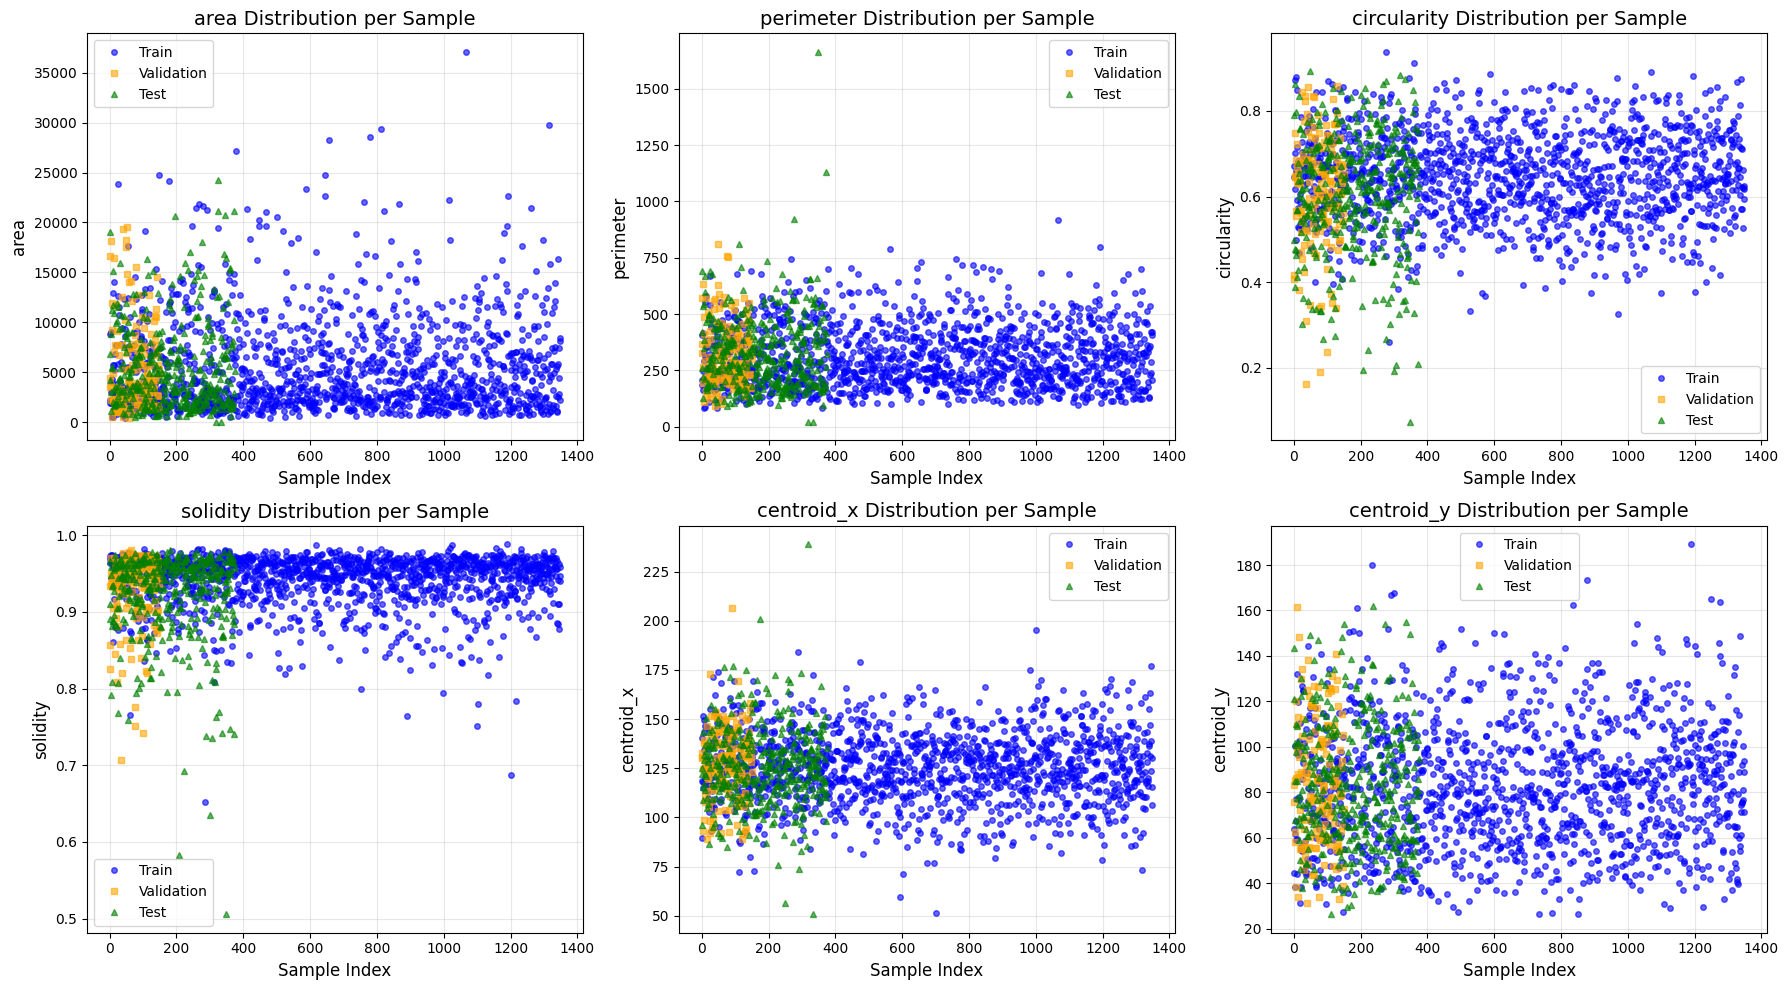

In [26]:
# ===========================================================
# STEP 16c: Plot BUSBRA Morphology Feature Values per Sample
# ===========================================================

import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Morphology features to visualize
# -----------------------------------------------------------
features_to_plot = [
    'area',
    'perimeter',
    'circularity',
    'solidity',
    'centroid_x',
    'centroid_y'
]

# -----------------------------------------------------------
# Colors for dataset splits
# -----------------------------------------------------------
colors = {
    'Train': 'blue',
    'Validation': 'orange',
    'Test': 'green'
}

# -----------------------------------------------------------
# Create figure
# -----------------------------------------------------------
plt.figure(figsize=(18, 10))

for i, feature in enumerate(features_to_plot):

    plt.subplot(2, 3, i + 1)

    # -------------------------------------------------------
    # Train features
    # -------------------------------------------------------
    plt.plot(
        train_features[feature].values,
        marker='o',
        linestyle='',
        markersize=4,
        color=colors['Train'],
        alpha=0.6,
        label='Train'
    )

    # -------------------------------------------------------
    # Validation features
    # -------------------------------------------------------
    plt.plot(
        val_features[feature].values,
        marker='s',
        linestyle='',
        markersize=4,
        color=colors['Validation'],
        alpha=0.6,
        label='Validation'
    )

    # -------------------------------------------------------
    # Test features
    # -------------------------------------------------------
    plt.plot(
        test_features[feature].values,
        marker='^',
        linestyle='',
        markersize=4,
        color=colors['Test'],
        alpha=0.6,
        label='Test'
    )

    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.title(f'{feature} Distribution per Sample', fontsize=14)

    plt.legend()
    plt.grid(alpha=0.3)

# -----------------------------------------------------------
# Final layout
# -----------------------------------------------------------
plt.tight_layout()
plt.show()

In [27]:
# ===========================================================
# STEP 17: Imports + Sanity Checks for BUSBRA Morphology Regression
# ===========================================================

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Morphology features used as LSTM inputs
feature_cols = [
    "area",
    "perimeter",
    "circularity",
    "solidity",
    "centroid_x",
    "centroid_y"
]

# Sanity check
for name, df in [
    ("train_features", train_features),
    ("val_features", val_features),
    ("test_features", test_features)
]:
    missing = [c for c in feature_cols if c not in df.columns]
    print(name, "shape:", df.shape, "missing:", missing)

print("Ready for LSTM morphology regression on BUSBRA.")

train_features shape: (1350, 6) missing: []
val_features shape: (150, 6) missing: []
test_features shape: (375, 6) missing: []
Ready for LSTM morphology regression on BUSBRA.


In [28]:
# ===========================================================
# STEP 18: Build X and Y for BUSBRA Multi-Target Morphology Regression
# ===========================================================

target_cols = [
    "area",
    "perimeter",
    "circularity",
    "solidity",
    "centroid_x",
    "centroid_y"
]

X_train_2d = train_features[feature_cols].values.astype(np.float64)
X_val_2d   = val_features[feature_cols].values.astype(np.float64)
X_test_2d  = test_features[feature_cols].values.astype(np.float64)

y_train_2d = train_features[target_cols].values.astype(np.float64)
y_val_2d   = val_features[target_cols].values.astype(np.float64)
y_test_2d  = test_features[target_cols].values.astype(np.float64)

print("X shapes:", X_train_2d.shape, X_val_2d.shape, X_test_2d.shape)
print("y shapes:", y_train_2d.shape, y_val_2d.shape, y_test_2d.shape)

X shapes: (1350, 6) (150, 6) (375, 6)
y shapes: (1350, 6) (150, 6) (375, 6)


In [29]:
# ===========================================================
# STEP 3: Replace NaN/Inf in X and y with column medians
# ===========================================================

def replace_nan_inf_with_col_median(arr2d):
    arr2d = arr2d.copy()
    col_median = np.nanmedian(arr2d, axis=0)

    inds_nan = np.isnan(arr2d)
    inds_inf = np.isinf(arr2d)

    if inds_nan.any():
        arr2d[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    if inds_inf.any():
        arr2d[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

    return arr2d

X_train_2d = replace_nan_inf_with_col_median(X_train_2d)
X_val_2d   = replace_nan_inf_with_col_median(X_val_2d)
X_test_2d  = replace_nan_inf_with_col_median(X_test_2d)

y_train_2d = replace_nan_inf_with_col_median(y_train_2d)
y_val_2d   = replace_nan_inf_with_col_median(y_val_2d)
y_test_2d  = replace_nan_inf_with_col_median(y_test_2d)

print("✅ NaN/Inf handled in X and y.")


✅ NaN/Inf handled in X and y.


In [30]:
# ===========================================================
# STEP 4: Log1p transform selected targets (optional but helps)
# We'll log1p only on area and perimeter (usually large scale).
# Circularity/solidity are already in [0,1], centroids are moderate.
# ===========================================================

log_cols = ["area", "perimeter"]  # edit if you want

log_idx = [target_cols.index(c) for c in log_cols]

def apply_log1p_on_cols(y2d, idxs):
    y2d = y2d.copy()
    y2d[:, idxs] = np.log1p(np.maximum(y2d[:, idxs], 0.0))
    return y2d

y_train_log = apply_log1p_on_cols(y_train_2d, log_idx)
y_val_log   = apply_log1p_on_cols(y_val_2d, log_idx)
y_test_log  = apply_log1p_on_cols(y_test_2d, log_idx)

print("✅ Log1p applied to:", log_cols)


✅ Log1p applied to: ['area', 'perimeter']


In [31]:
# ===========================================================
# STEP 5: Standardize X and y (fit on train only)
# ===========================================================

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d)
X_val_scaled   = scaler_X.transform(X_val_2d)
X_test_scaled  = scaler_X.transform(X_test_2d)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_log)
y_val_scaled   = scaler_y.transform(y_val_log)
y_test_scaled  = scaler_y.transform(y_test_log)

print("✅ Standardization done.")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled:", y_train_scaled.shape)


✅ Standardization done.
X_train_scaled: (1350, 6)
y_train_scaled: (1350, 6)


In [32]:
# ===========================================================
# STEP 6: Reshape for LSTM (timesteps=1)
# ===========================================================

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_val_lstm   = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

n_features = X_train_lstm.shape[2]
n_targets  = y_train_scaled.shape[1]

print("✅ LSTM input shape:", X_train_lstm.shape)
print("Targets:", n_targets, target_cols)


✅ LSTM input shape: (1350, 1, 6)
Targets: 6 ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']


In [33]:
# ===========================================================
# STEP 7: Build LSTM multi-target regression model
# ===========================================================

tf.keras.backend.clear_session()

inp = Input(shape=(1, n_features), name="morph_input")

x = LSTM(64, activation="tanh", return_sequences=False)(inp)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

out = Dense(n_targets, activation="linear", name="morph_regression")(x)

lstm_reg_model = Model(inp, out)
lstm_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae", "mse"]
)

lstm_reg_model.summary()
print("✅ LSTM regression model compiled.")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ morph_input (InputLayer)        │ (None, 1, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ morph_regression (Dense)        │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,726 (88.77 KB)

 Trainable params: 22,726 (88.77 KB)

 Non-trainable params: 0 (0.00 B)

✅ LSTM regression model compiled.


In [34]:
# ===========================================================
# STEP 8: Train BUSBRA LSTM Morphology Regression Model
# ===========================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import os

# -----------------------------------------------------------
# Save path
# -----------------------------------------------------------
lstm_model_path = os.path.join(
    dataset_path,
    "best_busbra_lstm_regression.keras"
)

# -----------------------------------------------------------
# Callbacks
# -----------------------------------------------------------
callbacks = [

    ModelCheckpoint(
        lstm_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# -----------------------------------------------------------
# Train model
# -----------------------------------------------------------
history = lstm_reg_model.fit(
    X_train_lstm,
    y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=150,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("✅ BUSBRA LSTM morphology regression trained.")

print("\nBest model saved at:")
print(lstm_model_path)

Epoch 1/150
83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8348 - mae: 0.7171 - mse: 0.8348
Epoch 1: val_loss improved from None to 0.41676, saving model to /content/drive/MyDrive/Colab Notebooks/BUSBRA/best_busbra_lstm_regression.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/BUSBRA/best_busbra_lstm_regression.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6693 - mae: 0.6334 - mse: 0.6693 - val_loss: 0.4168 - val_mae: 0.4540 - val_mse: 0.4168 - learning_rate: 0.0010
Epoch 2/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2471 - mae: 0.3702 - mse: 0.2471
Epoch 2: val_loss improved from 0.41676 to 0.09153, saving model to /content/drive/MyDrive/Colab Notebooks/BUSBRA/best_busbra_lstm_regression.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/BUSBRA/best_busbra_lstm_regression.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1910 - mae: 0.3252 - mse: 0.1910 - val_loss: 0.0915 - val_mae: 0.1952 - val_ms

In [35]:
# ===========================================================
# STEP 9: Predict + inverse transform back to original scale
# ===========================================================

y_pred_scaled = lstm_reg_model.predict(X_test_lstm, verbose=0)

# Inverse standardization
y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
y_true_log = scaler_y.inverse_transform(y_test_scaled)

# Undo log1p for selected columns
def undo_log1p_on_cols(y2d, idxs):
    y2d = y2d.copy()
    y2d[:, idxs] = np.expm1(y2d[:, idxs])
    return y2d

y_pred = undo_log1p_on_cols(y_pred_log, log_idx)
y_true = undo_log1p_on_cols(y_true_log, log_idx)

print("✅ Predictions transformed back to original scale.")
print("y_pred shape:", y_pred.shape)


✅ Predictions transformed back to original scale.
y_pred shape: (375, 6)


In [36]:
# ===========================================================
# STEP 10: Print regression results per target (MAE, MSE, RMSE, R2)
# ===========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for j, col in enumerate(target_cols):
    yt = y_true[:, j]
    yp = y_pred[:, j]

    mae = mean_absolute_error(yt, yp)
    mse = mean_squared_error(yt, yp)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(yt, yp)

    results.append([col, mae, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["target", "MAE", "MSE", "RMSE", "R2"])
print(results_df.to_string(index=False))

print("\n✅ First 10 predictions (per target):")
for j, col in enumerate(target_cols):
    print(col, "pred:", np.round(y_pred[:10, j], 4), "true:", np.round(y_true[:10, j], 4))


     target        MAE           MSE       RMSE       R2
       area 241.923771 176157.848568 419.711625 0.991032
  perimeter   9.278425   1312.495550  36.228380 0.952357
circularity   0.008210      0.000172   0.013129 0.991192
   solidity   0.003418      0.000117   0.010826 0.968164
 centroid_x   1.628474     10.090137   3.176498 0.976301
 centroid_y   1.759950      6.329139   2.515778 0.991465

✅ First 10 predictions (per target):
area pred: [ 4261.153  18309.088   6413.0664  8888.538   1200.2894  3061.9417
 10986.148   5382.6133  5587.817   1955.0938] true: [ 4246. 19059.  6779.  8833.  1095.  3031. 11221.  5412.  5515.  2059.]
perimeter pred: [263.9852 683.796  410.002  527.6054 132.0333 220.9345 536.7566 387.3216
 352.932  209.2452] true: [259.9655 693.2569 422.4335 533.73   126.2254 218.6518 544.8183 382.9361
 348.8356 213.4386]
circularity pred: [0.7766 0.4948 0.4766 0.3916 0.8498 0.7854 0.4755 0.4582 0.5676 0.5657] true: [0.7895 0.4983 0.4774 0.3897 0.8636 0.7967 0.475  0.4638 

In [37]:
# ===========================================================
# STEP: Compute Overall Regression Metrics for BUSBRA
# ===========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------------------------------------
# Compute overall metrics across all targets
# -----------------------------------------------------------
overall_mae = mean_absolute_error(y_true, y_pred)

overall_mse = mean_squared_error(y_true, y_pred)

overall_rmse = np.sqrt(overall_mse)

overall_r2 = r2_score(
    y_true,
    y_pred,
    multioutput='uniform_average'
)

# -----------------------------------------------------------
# Create summary table
# -----------------------------------------------------------
overall_results_df = pd.DataFrame({
    "Dataset": ["BUSBRA"],
    "MAE": [overall_mae],
    "MSE": [overall_mse],
    "RMSE": [overall_rmse],
    "R²": [overall_r2]
})

# -----------------------------------------------------------
# Print results
# -----------------------------------------------------------
print("\n=== Overall BUSBRA Regression Performance ===\n")

print(
    overall_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4e}"
    )
)


=== Overall BUSBRA Regression Performance ===

Dataset        MAE        MSE       RMSE         R²
 BUSBRA 4.2434e+01 2.9581e+04 1.7199e+02 9.7842e-01


In [39]:
# ===========================================================
# STEP: Print MSE, MAE, RMSE, R² for BUSBRA LSTM Regression
# ===========================================================

import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------------------------------------
# Overall regression metrics
# Averaged over all morphology targets and samples
# -----------------------------------------------------------
mae = mean_absolute_error(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_true,
    y_pred,
    multioutput='uniform_average'
)

# -----------------------------------------------------------
# Print results
# -----------------------------------------------------------
print("📊 Regression Performance (BUSBRA, all targets combined):")

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


📊 Regression Performance (BUSBRA, all targets combined):
MAE : 42.4337
MSE : 29581.1273
RMSE: 171.9916
R²  : 0.9784
